## EFM: Toy experiments

In [1]:
import torch

import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import sys
sys.path.append("/home/windowskonon1337/sources/FieldMatching")
from src.data import MultiDimStackedGauss, MultiDimStackedMixtureGauss, SwissRollSampler
from src.utils import Config
from src.efm_field import EFM
from src.ode import DippoleGroundTrurthEFMODESolver,  LearnDippoleEFMODESolver
from src.models  import DefineMLP, ToyNet

import warnings
warnings.filterwarnings('ignore')

/home/windowskonon1337/sources/FieldMatching/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Gaussian to Mixture

In [2]:
config = Config()

##### common #####
config.device = 'cuda' 
config.DIM = 3
config.L = 6.

config.KV = {"z":[-5,5.], "x":[1e-5,8.], "y": [-8,8]}
config.mesh_num_points = 7
##### common ##### 

##### p_data #####
config.p = Config()
config.p.dim = config.DIM -1
config.p.mean = (0.,0.)
config.p.x_loc = 0.
config.p.std = 1.
config.p.cov = None
##### p_data #####

##### q_data #####
config.q =  Config()
config.q.dim = config.DIM -1
config.q.num_components = 2
config.q.mix_probs = (0.5,0.5)
config.q.means = ((-8.,0.),(8.,0.))
config.q.stds = (1.,1.)
config.q.cov = None
config.q.x_loc = config.L
##### q_data #####

##### EFM #####
config.training = Config()

config.training = Config()
config.training.stability = True
config.training.gamma = 1e-7
config.training.epsilon=0.3
config.training.interpolation='mesh'
config.training.M = 20.
config.training.tau = .08
config.training.sigma_end = .8
config.training.batch_size =2048
config.training.small_batch_size =1024
config.training.restrict_M = False
config.training.training_steps = 8000
##### EFM #####

config.ode = Config()
config.ode.step = 1.   
config.ode.gamma = 0.
config.ode.behind_step = 1.5
config.ode.behind_num_steps = 350

da


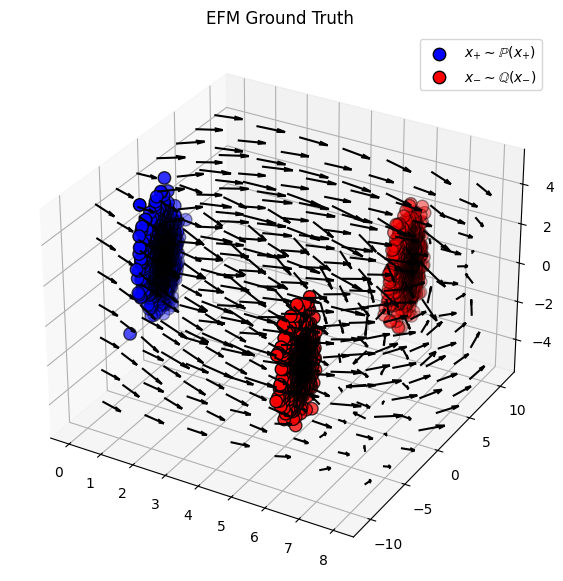

In [3]:
p_dist = MultiDimStackedGauss(config)
q_dist = MultiDimStackedMixtureGauss(config)

p_samples = p_dist.sample(config.training.batch_size).to(config.device)
q_samples = q_dist.sample(config.training.batch_size).to(config.device)
efm = EFM(config, learnable_masses=True)

mesh = efm.get_mesh(kv=config.KV,
                    mesh_num_points=config.mesh_num_points).to(config.device)
field = efm.GroundTruth(perturbed_samples_vec=mesh.clone(),
                        p_samples=p_samples, q_samples=q_samples)

fig = efm.plotVectorField(mesh=mesh, field=field,
                          p_samples=p_samples,
                          q_samples=q_samples)

In [4]:
ode = DippoleGroundTrurthEFMODESolver(config)
init = p_dist.sample(config.training.small_batch_size).to(config.device)
init[:,0] = config.training.epsilon
maps, traj = ode(efm, init , p_samples.clone(), q_samples.clone())
traj = torch.stack(traj,dim=0)

100%|██████████| 350/350 [00:03<00:00, 100.04it/s]


In [5]:
efm.log_mass_p, efm.log_mass_q

(tensor(0.0100, device='cuda:0', grad_fn=<ToCopyBackward0>),
 tensor(0.0100, device='cuda:0', grad_fn=<ToCopyBackward0>))

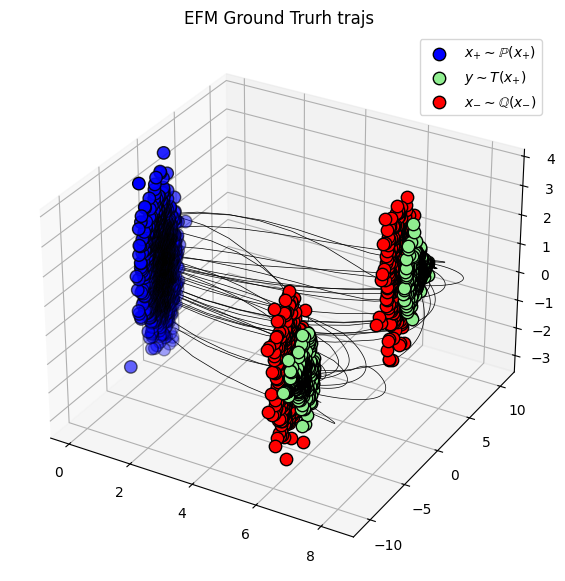

In [6]:
fig = efm.plotTrajectories(traj=traj, 
                           p_samples=p_samples,
                           q_samples=q_samples, title="EFM Ground Trurh trajs");

## 2. Gaussian to Swiss Roll

In [23]:
config = Config()

##### common #####
config.device = 'cuda' 
config.DIM = 3
config.L = 30.

config.KV = {"z":[-5,5.], "x":[1e-5,30.], "y": [-8,8]}
config.mesh_num_points = 7
##### common ##### 

##### p_data #####
config.p = Config()
config.p.dim = config.DIM -1
config.p.mean = (0.,0.)
config.p.x_loc = 0.
config.p.std = 1.
config.p.cov = None
##### p_data #####

##### q_data #####
config.q =  Config()
config.q.dim = config.DIM -1
config.q.x_loc = 30.
config.q.swiss_noise = None
##### q_data ##### 

##### EFM #####
config.training = Config()

config.training = Config()
config.training.stability = True
config.training.gamma = 1e-7
config.training.epsilon=0.3
config.training.interpolation='mesh'
config.training.M = 20.
config.training.tau = .08
config.training.sigma_end = .8
config.training.batch_size =2048
config.training.small_batch_size =1024
config.training.restrict_M = False
config.training.training_steps = 8000
##### EFM #####



config.model = Config()
config.model.embed_dim = 128
config.model.hidden_layers_x = [config.DIM-1, 1024*(config.DIM-1),
                                1024*(config.DIM-1),config.model.embed_dim]
config.model.hidden_layers = [ config.model.embed_dim, 1024*(config.DIM),
                              1024*(config.DIM), config.DIM]
config.model.lr =1e-4

##### ode #####
config.ode = Config()
config.ode.step = .5
config.ode.gamma = 0.
config.ode.behind_step = 1.5
config.ode.behind_num_steps = 350
##### ode #####

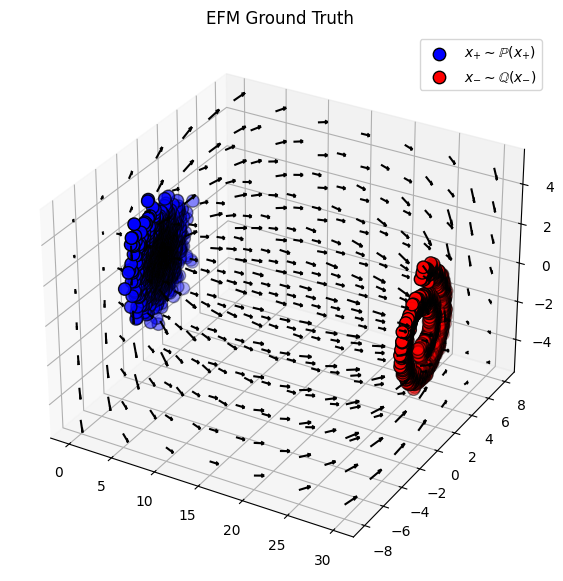

In [24]:
p_dist = MultiDimStackedGauss(config)
q_dist = SwissRollSampler(config)

p_samples = p_dist.sample(config.training.batch_size).to(config.device)
q_samples = q_dist.sample(config.training.batch_size).to(config.device)
efm = EFM(config)

mesh = efm.get_mesh(kv=config.KV,
                    mesh_num_points=config.mesh_num_points).to(config.device)
field = efm.GroundTruth(perturbed_samples_vec=mesh.clone(),
                        p_samples=p_samples, q_samples=q_samples)

fig = efm.plotVectorField(mesh=mesh, field=field,
                          p_samples=p_samples,
                          q_samples=q_samples)

In [25]:
config.ode.step = .5
config.ode.gamma = 0.
config.ode.behind_step = .025
config.ode.behind_num_steps = 650

In [26]:
ode = DippoleGroundTrurthEFMODESolver(config)
init = p_dist.sample(config.training.small_batch_size).to(config.device)
init[:,0] = config.training.epsilon
maps, traj = ode(efm, init , p_samples.clone(), q_samples.clone())
traj = torch.stack(traj,dim=0)

100%|██████████| 650/650 [00:01<00:00, 398.46it/s]


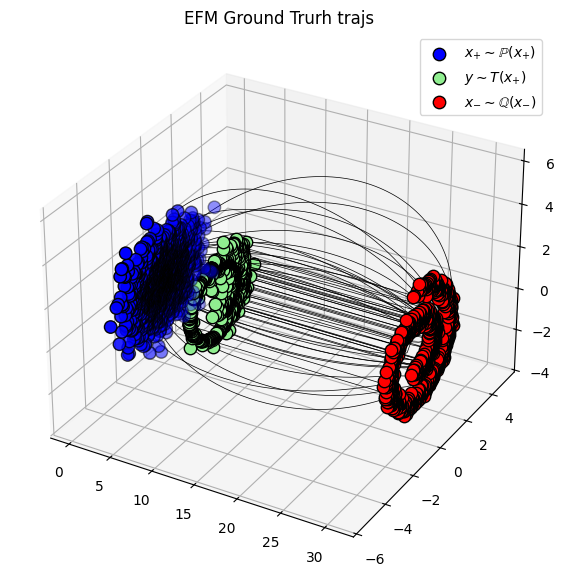

In [27]:
fig = efm.plotTrajectories(traj=traj, 
                           p_samples=p_samples,
                           q_samples=q_samples, title="EFM Ground Trurh trajs");

## 3. Обучение ToyModel: сравнение с обучаемыми и фиксированными массами


In [10]:
# Используем конфигурацию из Cell 3 (Gaussian to Mixture)
# Добавляем конфигурацию модели
config.model = Config()
config.model.embed_dim = 128
config.model.hidden_layers_x = [config.DIM-1, 256, 256, config.model.embed_dim]
config.model.hidden_layers = [config.model.embed_dim, 256, 256, config.DIM]
config.model.lr = 1e-4

# Подготовка данных
p_dist = MultiDimStackedGauss(config)
q_dist = MultiDimStackedMixtureGauss(config)

# Тестовые выборки для оценки
test_p_samples = p_dist.sample(500).to(config.device)
test_q_samples = q_dist.sample(500).to(config.device)

print("Конфигурация готова для обучения")


AttributeError: 'Config' object has no attribute 'num_components'

In [12]:
# Обучение модели БЕЗ обучаемых масс (базовая модель)
print("=" * 60)
print("Обучение модели БЕЗ обучаемых масс")
print("=" * 60)

# Создаем EFM без обучаемых масс
efm_fixed = EFM(config, learnable_masses=False)

# Создаем модель
model_x = DefineMLP(config.model.hidden_layers_x)
model = DefineMLP(config.model.hidden_layers)
net_fixed = ToyNet(model_x, model, config).to(config.device)

# Создаем оптимизатор только для сети
optimizer_fixed = torch.optim.Adam(net_fixed.parameters(), lr=config.model.lr)

# Обучение
print(f"Начинаем обучение на {config.training.training_steps} шагов...")
net_fixed, losses_fixed = efm_fixed.Toytrain(
    p_dist, q_dist, net_fixed, optimizer_fixed,
    verbose=False
)

print(f"Обучение завершено. Финальный loss: {losses_fixed[-1]:.6f}")
print(f"Массы (фиксированные): mass_p=1.0, mass_q=1.0")


Обучение модели БЕЗ обучаемых масс
Начинаем обучение на 8000 шагов...


100%|██████████| 8000/8000 [00:59<00:00, 135.29it/s]

Обучение завершено. Финальный loss: 0.009145
Массы (фиксированные): mass_p=1.0, mass_q=1.0


In [13]:
# Обучение модели С обучаемыми массами
print("=" * 60)
print("Обучение модели С обучаемыми массами")
print("=" * 60)

# Создаем EFM с обучаемыми массами
efm_learnable = EFM(config, learnable_masses=True)

# Создаем модель (новая инициализация)
model_x = DefineMLP(config.model.hidden_layers_x)
model = DefineMLP(config.model.hidden_layers)
net_learnable = ToyNet(model_x, model, config).to(config.device)
# Создаем оптимизатор для сети
optimizer_learnable = torch.optim.Adam(net_learnable.parameters(), lr=config.model.lr)

# Обучение (параметры масс будут добавлены в оптимизатор внутри Toytrain)
print(f"Начинаем обучение на {config.training.training_steps} шагов...")
print(f"Начальные массы: mass_p={torch.exp(efm_learnable.log_mass_p).item():.6f}, mass_q={torch.exp(efm_learnable.log_mass_q).item():.6f}")

net_learnable, losses_learnable = efm_learnable.Toytrain(
    p_dist, q_dist, net_learnable, optimizer_learnable,
    mass_lr=1e-3,  # Learning rate для масс
    mass_reg_weight=0.01,  # Вес регуляризации
    verbose=False
)

final_mass_p = torch.exp(efm_learnable.log_mass_p).item()
final_mass_q = torch.exp(efm_learnable.log_mass_q).item()

print(f"Обучение завершено. Финальный loss: {losses_learnable[-1]:.6f}")
print(f"Финальные массы: mass_p={final_mass_p:.6f}, mass_q={final_mass_q:.6f}")
print(f"log_mass_p={efm_learnable.log_mass_p.item():.6f}, log_mass_q={efm_learnable.log_mass_q.item():.6f}")


Обучение модели С обучаемыми массами
Начинаем обучение на 8000 шагов...
Начальные массы: mass_p=1.000000, mass_q=1.000000


100%|██████████| 8000/8000 [01:03<00:00, 126.43it/s]

Обучение завершено. Финальный loss: 0.001684
Финальные массы: mass_p=0.291746, mass_q=0.575455
log_mass_p=-1.231870, log_mass_q=-0.552595


In [15]:
# Функции для вычисления метрик
def compute_field_mse(efm, net, test_samples, p_samples, q_samples, n_points=100):
    """Вычисляет MSE между предсказанным полем и ground truth."""
    # Создаем тестовые точки
    test_points = test_samples[:n_points].clone()
    
    # Ground truth поле
    with torch.no_grad():
        gt_field = efm.GroundTruth(test_points, p_samples, q_samples)
        pred_field = net(test_points)
        mse = torch.mean((gt_field - pred_field)**2).item()
    return mse

def compute_trajectory_error(efm, net, init_points, q_samples, ode_solver):
    """Вычисляет среднее расстояние между конечными точками траекторий и целевым распределением."""
    with torch.no_grad():
        # Используем обученную сеть для решения ODE
        learned_ode = LearnDippoleEFMODESolver(net, config)
        
        # Подготовка входных данных для ODE solver
        p_samples_ode = torch.cat([config.p.x_loc*torch.ones(len(init_points))[:,None].to(config.device),
                                   init_points[:,1:]], dim=1)
        q_samples_ode = torch.cat([config.q.x_loc*torch.ones(len(q_samples))[:,None].to(config.device),
                                  q_samples[:,1:]], dim=1) if q_samples.shape[1] == 2 else q_samples
        
        final_points, _ = learned_ode(init_points.clone(), p_samples_ode, q_samples_ode)
        
        # Берем только пространственные координаты (без z)
        final_x = final_points[:, 1:]  # [n, 2]
        target_x = q_samples[:, 1:] if q_samples.shape[1] > 1 else q_samples  # [m, 2]
        
        # Вычисляем минимальное расстояние от каждой конечной точки до целевого распределения
        distances = []
        for i in range(len(final_x)):
            dists = torch.norm(final_x[i:i+1] - target_x, dim=1)
            distances.append(torch.min(dists).item())
        
        return np.mean(distances)

def compute_wasserstein_1(efm, net, init_points, q_samples, ode_solver):
    """Вычисляет Wasserstein-1 distance (Earth Mover's Distance) между конечными точками траекторий и целевым распределением."""
    with torch.no_grad():
        # Используем обученную сеть для решения ODE
        learned_ode = LearnDippoleEFMODESolver(net, config)
        
        # Подготовка входных данных для ODE solver
        p_samples_ode = torch.cat([config.p.x_loc*torch.ones(len(init_points))[:,None].to(config.device),
                                   init_points[:,1:]], dim=1)
        q_samples_ode = torch.cat([config.q.x_loc*torch.ones(len(q_samples))[:,None].to(config.device),
                                  q_samples[:,1:]], dim=1) if q_samples.shape[1] == 2 else q_samples
        
        final_points, _ = learned_ode(init_points.clone(), p_samples_ode, q_samples_ode)
        
        # Берем только пространственные координаты (без z)
        final_x = final_points[:, 1:].detach().cpu().numpy()  # [n, 2]
        target_x = q_samples[:, 1:].detach().cpu().numpy() if q_samples.shape[1] > 1 else q_samples.detach().cpu().numpy()  # [m, 2]
        
        # Вычисляем Wasserstein-1 distance
        # Для многомерного случая используем оптимальный транспорт
        try:
            from scipy.stats import wasserstein_distance
            # Для 2D: вычисляем по каждой координате и усредняем, или используем библиотеку POT
            # Простой способ: используем scipy.stats для каждой координаты
            if final_x.shape[1] == 1:
                wd = wasserstein_distance(final_x.flatten(), target_x.flatten())
            else:
                # Для многомерного: вычисляем по каждой координате и усредняем
                wd_list = []
                for dim in range(final_x.shape[1]):
                    wd_dim = wasserstein_distance(final_x[:, dim], target_x[:, dim])
                    wd_list.append(wd_dim)
                wd = np.mean(wd_list)
        except ImportError:
            # Fallback: используем приближенный метод через минимальные расстояния
            from scipy.spatial.distance import cdist
            distances = cdist(final_x, target_x)
            # Приближение: среднее минимальное расстояние (не совсем Wasserstein, но близко)
            min_dists = np.min(distances, axis=1)
            wd = np.mean(min_dists)
        
        return wd


In [15]:
# Вычисление метрик для обеих моделей
print("=" * 60)
print("ВЫЧИСЛЕНИЕ МЕТРИК")
print("=" * 60)

# Подготовка тестовых данных
test_init = p_dist.sample(100).to(config.device)
test_init[:, 0] = config.training.epsilon

# Метрика 1: Field MSE (точность предсказания поля)
print("\n1. Field MSE (MSE между предсказанным полем и ground truth):")
field_mse_fixed = compute_field_mse(efm_fixed, net_fixed, test_init, test_p_samples, test_q_samples)
field_mse_learnable = compute_field_mse(efm_learnable, net_learnable, test_init, test_p_samples, test_q_samples)

print(f"  Модель с фиксированными массами: {field_mse_fixed:.6f}")
print(f"  Модель с обучаемыми массами:     {field_mse_learnable:.6f}")
print(f"  Улучшение: {((field_mse_fixed - field_mse_learnable) / field_mse_fixed * 100):.2f}%")

# Метрика 2: Trajectory Error (точность траекторий)
print("\n2. Trajectory Error (среднее расстояние до целевого распределения):")
try:
    traj_error_fixed = compute_trajectory_error(efm_fixed, net_fixed, test_init, test_q_samples, None)
    traj_error_learnable = compute_trajectory_error(efm_learnable, net_learnable, test_init, test_q_samples, None)
    
    print(f"  Модель с фиксированными массами: {traj_error_fixed:.6f}")
    print(f"  Модель с обучаемыми массами:     {traj_error_learnable:.6f}")
    print(f"  Улучшение: {((traj_error_fixed - traj_error_learnable) / traj_error_fixed * 100):.2f}%")
except Exception as e:
    print(f"  Ошибка при вычислении: {e}")
    traj_error_fixed = None
    traj_error_learnable = None

# Метрика 3: Training Loss (сравнение кривых обучения)
print("\n3. Training Loss (финальные значения):")
print(f"  Модель с фиксированными массами: {losses_fixed[-1]:.6f}")
print(f"  Модель с обучаемыми массами:     {losses_learnable[-1]:.6f}")
print(f"  Улучшение: {((losses_fixed[-1] - losses_learnable[-1]) / losses_fixed[-1] * 100):.2f}%")

# Сводная таблица
print("\n" + "=" * 60)
print("СВОДНАЯ ТАБЛИЦА МЕТРИК")
print("=" * 60)
print(f"{'Метрика':<30} {'Фиксированные':<20} {'Обучаемые':<20} {'Улучшение':<15}")
print("-" * 85)
print(f"{'Field MSE':<30} {field_mse_fixed:<20.6f} {field_mse_learnable:<20.6f} {((field_mse_fixed - field_mse_learnable) / field_mse_fixed * 100):>13.2f}%")
if traj_error_fixed is not None:
    print(f"{'Trajectory Error':<30} {traj_error_fixed:<20.6f} {traj_error_learnable:<20.6f} {((traj_error_fixed - traj_error_learnable) / traj_error_fixed * 100):>13.2f}%")
print(f"{'Training Loss (final)':<30} {losses_fixed[-1]:<20.6f} {losses_learnable[-1]:<20.6f} {((losses_fixed[-1] - losses_learnable[-1]) / losses_fixed[-1] * 100):>13.2f}%")
print(f"{'Mass P':<30} {'1.000000':<20} {final_mass_p:<20.6f} {'-':<15}")
print(f"{'Mass Q':<30} {'1.000000':<20} {final_mass_q:<20.6f} {'-':<15}")
print("=" * 60)


ВЫЧИСЛЕНИЕ МЕТРИК

1. Field MSE (MSE между предсказанным полем и ground truth):
  Модель с фиксированными массами: 0.362795
  Модель с обучаемыми массами:     0.028262
  Улучшение: 92.21%

2. Trajectory Error (среднее расстояние до целевого распределения):


100%|██████████| 350/350 [00:00<00:00, 1334.12it/s]

  Модель с фиксированными массами: 1.703609
  Модель с обучаемыми массами:     0.382993
  Улучшение: 77.52%

3. Training Loss (финальные значения):
  Модель с фиксированными массами: 0.009145
  Модель с обучаемыми массами:     0.001684
  Улучшение: 81.58%

СВОДНАЯ ТАБЛИЦА МЕТРИК
Метрика                        Фиксированные        Обучаемые            Улучшение      
-------------------------------------------------------------------------------------
Field MSE                      0.362795             0.028262                     92.21%
Trajectory Error               1.703609             0.382993                     77.52%
Training Loss (final)          0.009145             0.001684                     81.58%
Mass P                         1.000000             0.291746             -              
Mass Q                         1.000000             0.575455             -              


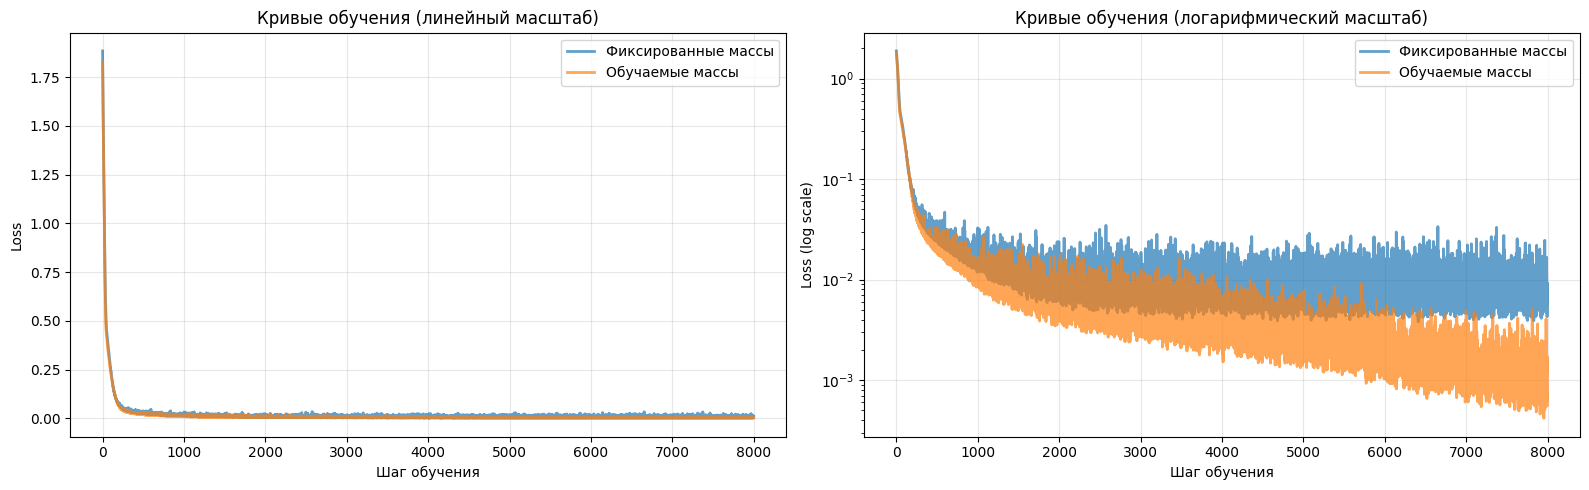


Финальные значения loss:
  Фиксированные массы: 0.009145
  Обучаемые массы:     0.001684


In [16]:
# Визуализация сравнения: кривые обучения
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Кривые обучения (линейный масштаб)
ax1 = axes[0]
ax1.plot(losses_fixed, label='Фиксированные массы', alpha=0.7, linewidth=2)
ax1.plot(losses_learnable, label='Обучаемые массы', alpha=0.7, linewidth=2)
ax1.set_xlabel('Шаг обучения')
ax1.set_ylabel('Loss')
ax1.set_title('Кривые обучения (линейный масштаб)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Кривые обучения (логарифмический масштаб)
ax2 = axes[1]
ax2.semilogy(losses_fixed, label='Фиксированные массы', alpha=0.7, linewidth=2)
ax2.semilogy(losses_learnable, label='Обучаемые массы', alpha=0.7, linewidth=2)
ax2.set_xlabel('Шаг обучения')
ax2.set_ylabel('Loss (log scale)')
ax2.set_title('Кривые обучения (логарифмический масштаб)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nФинальные значения loss:")
print(f"  Фиксированные массы: {losses_fixed[-1]:.6f}")
print(f"  Обучаемые массы:     {losses_learnable[-1]:.6f}")


Генерация траекторий для визуализации...


100%|██████████| 350/350 [00:00<00:00, 1174.45it/s]


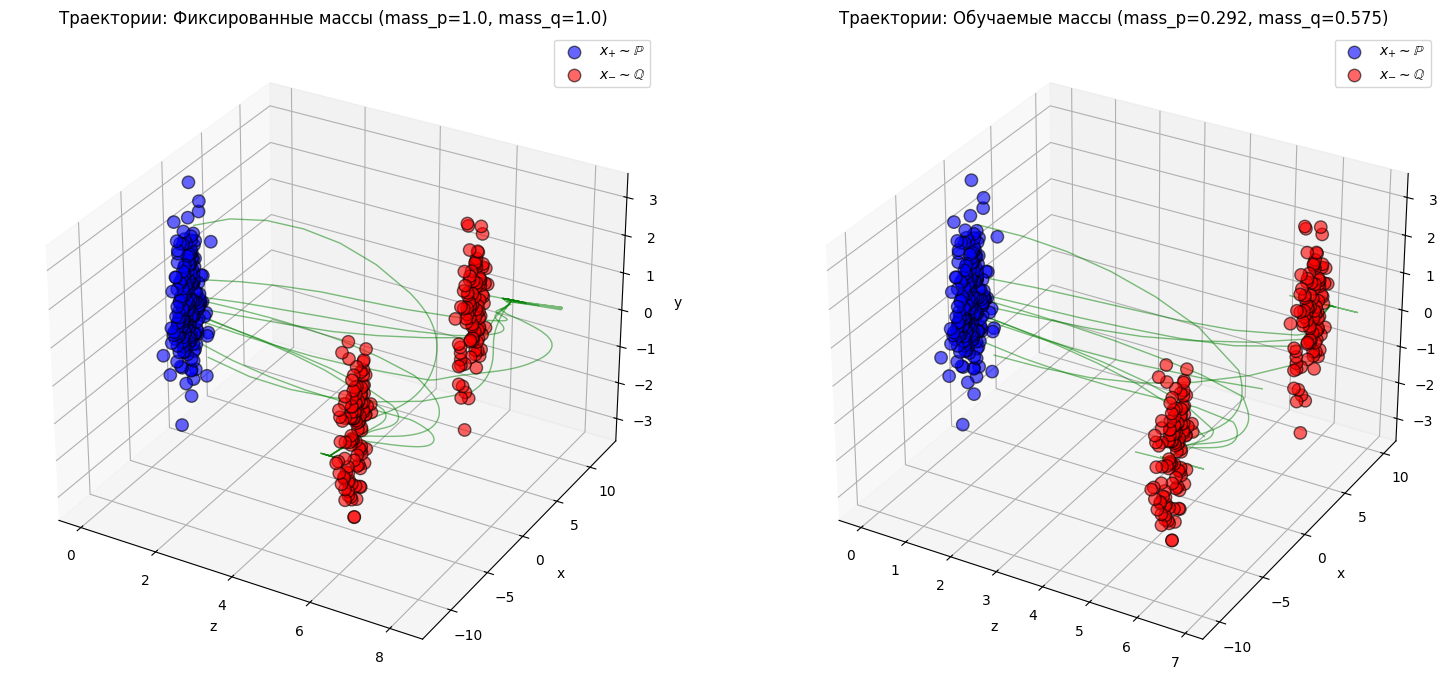

In [17]:
# Визуализация траекторий для обеих моделей
print("Генерация траекторий для визуализации...")

# Траектории для модели с фиксированными массами
learned_ode_fixed = LearnDippoleEFMODESolver(net_fixed, config)
init_viz = p_dist.sample(50).to(config.device)
init_viz[:, 0] = config.training.epsilon

p_samples_viz = p_dist.sample(200).to(config.device)
q_samples_viz = q_dist.sample(200).to(config.device)

try:
    p_samples_ode = torch.cat([config.p.x_loc*torch.ones(len(p_samples_viz))[:,None].to(config.device),
                               p_samples_viz[:,1:]], dim=1)
    q_samples_ode = torch.cat([config.q.x_loc*torch.ones(len(q_samples_viz))[:,None].to(config.device),
                              q_samples_viz[:,1:]], dim=1)
    
    _, traj_fixed = learned_ode_fixed(init_viz.clone(), p_samples_ode, q_samples_ode)
    traj_fixed = torch.stack(traj_fixed, dim=0)
except Exception as e:
    print(f"Ошибка при генерации траекторий (фиксированные): {e}")
    # Fallback: используем ground truth ODE solver
    ode_solver = DippoleGroundTrurthEFMODESolver(config)
    _, traj_fixed = ode_solver(efm_fixed, init_viz.clone(), p_samples_ode, q_samples_ode)
    traj_fixed = torch.stack(traj_fixed, dim=0)

# Траектории для модели с обучаемыми массами
try:
    learned_ode_learnable = LearnDippoleEFMODESolver(net_learnable, config)
    _, traj_learnable = learned_ode_learnable(init_viz.clone(), p_samples_ode, q_samples_ode)
    traj_learnable = torch.stack(traj_learnable, dim=0)
except Exception as e:
    print(f"Ошибка при генерации траекторий (обучаемые): {e}")
    ode_solver = DippoleGroundTrurthEFMODESolver(config)
    _, traj_learnable = ode_solver(efm_learnable, init_viz.clone(), p_samples_ode, q_samples_ode)
    traj_learnable = torch.stack(traj_learnable, dim=0)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 7), subplot_kw={'projection': '3d'})

# Модель с фиксированными массами
ax1 = axes[0]
ax1.scatter(p_samples_viz[:,0].detach().cpu(), p_samples_viz[:,1].detach().cpu(), p_samples_viz[:,2].detach().cpu(),
           color='blue', edgecolor='black', s=80, label=r'$x_{+} \sim \mathbb{P}$', alpha=0.6)
ax1.scatter(q_samples_viz[:,0].detach().cpu(), q_samples_viz[:,1].detach().cpu(), q_samples_viz[:,2].detach().cpu(),
           color='red', edgecolor='black', s=80, label=r'$x_{-} \sim \mathbb{Q}$', alpha=0.6)

# Показываем несколько траекторий
for i in range(min(10, len(init_viz))):
    if len(traj_fixed.shape) == 3:
        ax1.plot(traj_fixed[:, i, 0].detach().cpu(), 
                traj_fixed[:, i, 1].detach().cpu(),
                traj_fixed[:, i, 2].detach().cpu(),
                color='green', alpha=0.5, linewidth=1)

ax1.set_title('Траектории: Фиксированные массы (mass_p=1.0, mass_q=1.0)')
ax1.legend()
ax1.set_xlabel('z')
ax1.set_ylabel('x')
ax1.set_zlabel('y')

# Модель с обучаемыми массами
ax2 = axes[1]
ax2.scatter(p_samples_viz[:,0].detach().cpu(), p_samples_viz[:,1].detach().cpu(), p_samples_viz[:,2].detach().cpu(),
           color='blue', edgecolor='black', s=80, label=r'$x_{+} \sim \mathbb{P}$', alpha=0.6)
ax2.scatter(q_samples_viz[:,0].detach().cpu(), q_samples_viz[:,1].detach().cpu(), q_samples_viz[:,2].detach().cpu(),
           color='red', edgecolor='black', s=80, label=r'$x_{-} \sim \mathbb{Q}$', alpha=0.6)

for i in range(min(10, len(init_viz))):
    if len(traj_learnable.shape) == 3:
        ax2.plot(traj_learnable[:, i, 0].detach().cpu(), 
                traj_learnable[:, i, 1].detach().cpu(),
                traj_learnable[:, i, 2].detach().cpu(),
                color='green', alpha=0.5, linewidth=1)

ax2.set_title(f'Траектории: Обучаемые массы (mass_p={final_mass_p:.3f}, mass_q={final_mass_q:.3f})')
ax2.legend()
ax2.set_xlabel('z')
ax2.set_ylabel('x')
ax2.set_zlabel('y')

plt.tight_layout()
plt.show()


## Swiss roll

In [28]:
# Используем конфигурацию из Cell 3 (Gaussian to Mixture)
# Добавляем конфигурацию модели
config.model = Config()
config.model.embed_dim = 128
config.model.hidden_layers_x = [config.DIM-1, 256, 256, config.model.embed_dim]
config.model.hidden_layers = [config.model.embed_dim, 256, 256, config.DIM]
config.model.lr = 1e-4

# Подготовка данных
p_dist = MultiDimStackedGauss(config)
q_dist = SwissRollSampler(config)

# Тестовые выборки для оценки
test_p_samples = p_dist.sample(500).to(config.device)
test_q_samples = q_dist.sample(500).to(config.device)

print("Конфигурация готова для обучения")


Конфигурация готова для обучения


In [29]:
# Обучение модели БЕЗ обучаемых масс (базовая модель)
print("=" * 60)
print("Обучение модели БЕЗ обучаемых масс")
print("=" * 60)

# Создаем EFM без обучаемых масс
efm_fixed = EFM(config, learnable_masses=False)

# Создаем модель
model_x = DefineMLP(config.model.hidden_layers_x)
model = DefineMLP(config.model.hidden_layers)
net_fixed = ToyNet(model_x, model, config).to(config.device)

# Создаем оптимизатор только для сети
optimizer_fixed = torch.optim.Adam(net_fixed.parameters(), lr=config.model.lr)

# Обучение
print(f"Начинаем обучение на {config.training.training_steps} шагов...")
net_fixed, losses_fixed = efm_fixed.Toytrain(
    p_dist, q_dist, net_fixed, optimizer_fixed,
    verbose=False
)

print(f"Обучение завершено. Финальный loss: {losses_fixed[-1]:.6f}")
print(f"Массы (фиксированные): mass_p=1.0, mass_q=1.0")


Обучение модели БЕЗ обучаемых масс
Начинаем обучение на 8000 шагов...


100%|██████████| 8000/8000 [01:03<00:00, 126.15it/s]

Обучение завершено. Финальный loss: 0.014765
Массы (фиксированные): mass_p=1.0, mass_q=1.0


In [30]:
# Обучение модели С обучаемыми массами
print("=" * 60)
print("Обучение модели С обучаемыми массами")
print("=" * 60)

# Создаем EFM с обучаемыми массами
efm_learnable = EFM(config, learnable_masses=True)

# Создаем модель (новая инициализация)
model_x = DefineMLP(config.model.hidden_layers_x)
model = DefineMLP(config.model.hidden_layers)
net_learnable = ToyNet(model_x, model, config).to(config.device)
# Создаем оптимизатор для сети
optimizer_learnable = torch.optim.Adam(net_learnable.parameters(), lr=config.model.lr)

# Обучение (параметры масс будут добавлены в оптимизатор внутри Toytrain)
print(f"Начинаем обучение на {config.training.training_steps} шагов...")
print(f"Начальные массы: mass_p={torch.exp(efm_learnable.log_mass_p).item():.6f}, mass_q={torch.exp(efm_learnable.log_mass_q).item():.6f}")

net_learnable, losses_learnable = efm_learnable.Toytrain(
    p_dist, q_dist, net_learnable, optimizer_learnable,
    mass_lr=1e-3,  # Learning rate для масс
    mass_reg_weight=0.01,  # Вес регуляризации
    verbose=False
)

final_mass_p = torch.exp(efm_learnable.log_mass_p).item()
final_mass_q = torch.exp(efm_learnable.log_mass_q).item()

print(f"Обучение завершено. Финальный loss: {losses_learnable[-1]:.6f}")
print(f"Финальные массы: mass_p={final_mass_p:.6f}, mass_q={final_mass_q:.6f}")
print(f"log_mass_p={efm_learnable.log_mass_p.item():.6f}, log_mass_q={efm_learnable.log_mass_q.item():.6f}")


Обучение модели С обучаемыми массами
Начинаем обучение на 8000 шагов...
Начальные массы: mass_p=1.000000, mass_q=1.000000


100%|██████████| 8000/8000 [01:06<00:00, 119.62it/s]

Обучение завершено. Финальный loss: 0.001776
Финальные массы: mass_p=0.350000, mass_q=0.413883
log_mass_p=-1.049823, log_mass_q=-0.882173


In [16]:
# Вычисление метрик для обеих моделей
print("=" * 60)
print("ВЫЧИСЛЕНИЕ МЕТРИК")
print("=" * 60)

# Подготовка тестовых данных
test_init = p_dist.sample(100).to(config.device)
test_init[:, 0] = config.training.epsilon

# Метрика 1: Field MSE (точность предсказания поля)
print("\n1. Field MSE (MSE между предсказанным полем и ground truth):")
field_mse_fixed = compute_field_mse(efm_fixed, net_fixed, test_init, test_p_samples, test_q_samples)
field_mse_learnable = compute_field_mse(efm_learnable, net_learnable, test_init, test_p_samples, test_q_samples)

print(f"  Модель с фиксированными массами: {field_mse_fixed:.6f}")
print(f"  Модель с обучаемыми массами:     {field_mse_learnable:.6f}")
print(f"  Улучшение: {((field_mse_fixed - field_mse_learnable) / field_mse_fixed * 100):.2f}%")

# Метрика 2: Trajectory Error (точность траекторий)
print("\n2. Wasserstein-1 Distance (расстояние между распределениями):")
try:
    wass1_fixed = compute_wasserstein_1(efm_fixed, net_fixed, test_init, test_q_samples, None)
    wass1_learnable = compute_wasserstein_1(efm_learnable, net_learnable, test_init, test_q_samples, None)
    
    print(f"  Модель с фиксированными массами: {wass1_fixed:.6f}")
    print(f"  Модель с обучаемыми массами:     {wass1_learnable:.6f}")
    print(f"  Улучшение: {((wass1_fixed - wass1_learnable) / wass1_fixed * 100):.2f}%")
except Exception as e:
    print(f"  Ошибка при вычислении: {e}")
    wass1_fixed = None
    wass1_learnable = None

# Метрика 3: Training Loss (сравнение кривых обучения)
print("\n3. Training Loss (финальные значения):")
print(f"  Модель с фиксированными массами: {losses_fixed[-1]:.6f}")
print(f"  Модель с обучаемыми массами:     {losses_learnable[-1]:.6f}")
print(f"  Улучшение: {((losses_fixed[-1] - losses_learnable[-1]) / losses_fixed[-1] * 100):.2f}%")

# Сводная таблица
print("\n" + "=" * 60)
print("СВОДНАЯ ТАБЛИЦА МЕТРИК")
print("=" * 60)
print(f"{'Метрика':<30} {'Фиксированные':<20} {'Обучаемые':<20} {'Улучшение':<15}")
print("-" * 85)
print(f"{'Field MSE':<30} {field_mse_fixed:<20.6f} {field_mse_learnable:<20.6f} {((field_mse_fixed - field_mse_learnable) / field_mse_fixed * 100):>13.2f}%")
if traj_error_fixed is not None:
    print(f"{'Trajectory Error':<30} {traj_error_fixed:<20.6f} {traj_error_learnable:<20.6f} {((traj_error_fixed - traj_error_learnable) / traj_error_fixed * 100):>13.2f}%")
print(f"{'Training Loss (final)':<30} {losses_fixed[-1]:<20.6f} {losses_learnable[-1]:<20.6f} {((losses_fixed[-1] - losses_learnable[-1]) / losses_fixed[-1] * 100):>13.2f}%")
print(f"{'Mass P':<30} {'1.000000':<20} {final_mass_p:<20.6f} {'-':<15}")
print(f"{'Mass Q':<30} {'1.000000':<20} {final_mass_q:<20.6f} {'-':<15}")
print("=" * 60)


ВЫЧИСЛЕНИЕ МЕТРИК

1. Field MSE (MSE между предсказанным полем и ground truth):
  Модель с фиксированными массами: 0.317549
  Модель с обучаемыми массами:     0.008036
  Улучшение: 97.47%

2. Wasserstein-1 Distance (расстояние между распределениями):


100%|██████████| 650/650 [00:00<00:00, 977.90it/s]

  Модель с фиксированными массами: 13.975339
  Модель с обучаемыми массами:     42.143893
  Улучшение: -201.56%

3. Training Loss (финальные значения):
  Модель с фиксированными массами: 0.004829
  Модель с обучаемыми массами:     0.000445
  Улучшение: 90.79%

СВОДНАЯ ТАБЛИЦА МЕТРИК
Метрика                        Фиксированные        Обучаемые            Улучшение      
-------------------------------------------------------------------------------------
Field MSE                      0.317549             0.008036                     97.47%


NameError: name 'traj_error_fixed' is not defined

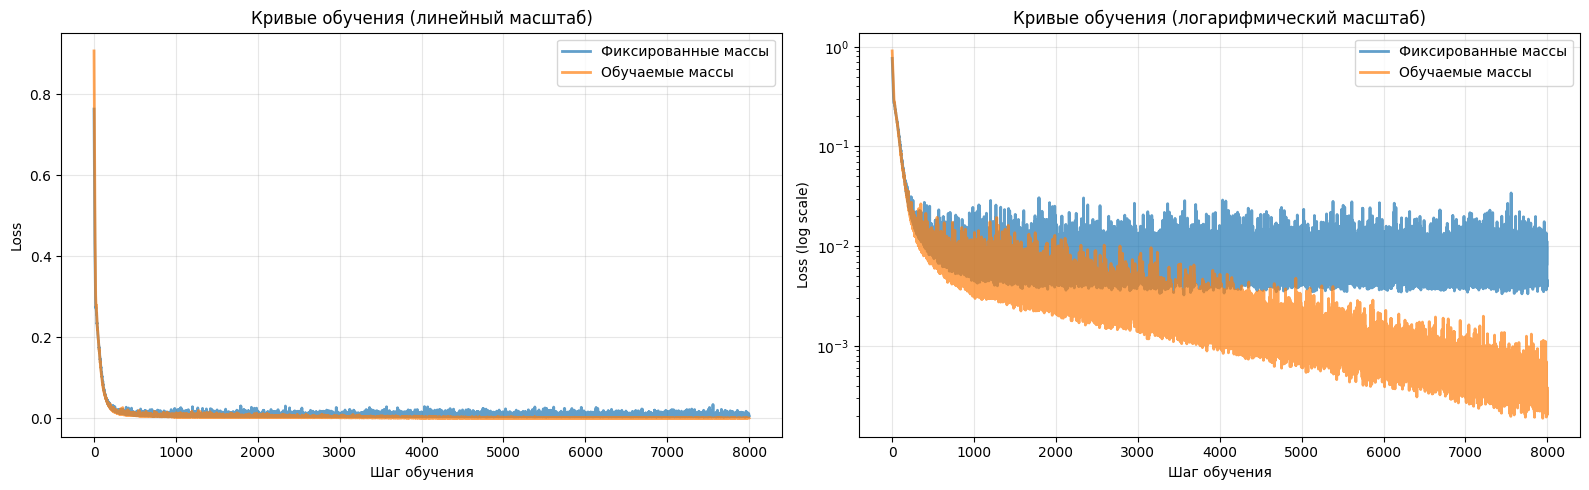


Финальные значения loss:
  Фиксированные массы: 0.004495
  Обучаемые массы:     0.000374


In [27]:
# Визуализация сравнения: кривые обучения
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Кривые обучения (линейный масштаб)
ax1 = axes[0]
ax1.plot(losses_fixed, label='Фиксированные массы', alpha=0.7, linewidth=2)
ax1.plot(losses_learnable, label='Обучаемые массы', alpha=0.7, linewidth=2)
ax1.set_xlabel('Шаг обучения')
ax1.set_ylabel('Loss')
ax1.set_title('Кривые обучения (линейный масштаб)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Кривые обучения (логарифмический масштаб)
ax2 = axes[1]
ax2.semilogy(losses_fixed, label='Фиксированные массы', alpha=0.7, linewidth=2)
ax2.semilogy(losses_learnable, label='Обучаемые массы', alpha=0.7, linewidth=2)
ax2.set_xlabel('Шаг обучения')
ax2.set_ylabel('Loss (log scale)')
ax2.set_title('Кривые обучения (логарифмический масштаб)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nФинальные значения loss:")
print(f"  Фиксированные массы: {losses_fixed[-1]:.6f}")
print(f"  Обучаемые массы:     {losses_learnable[-1]:.6f}")


Генерация траекторий для визуализации...


100%|██████████| 650/650 [00:00<00:00, 822.80it/s]


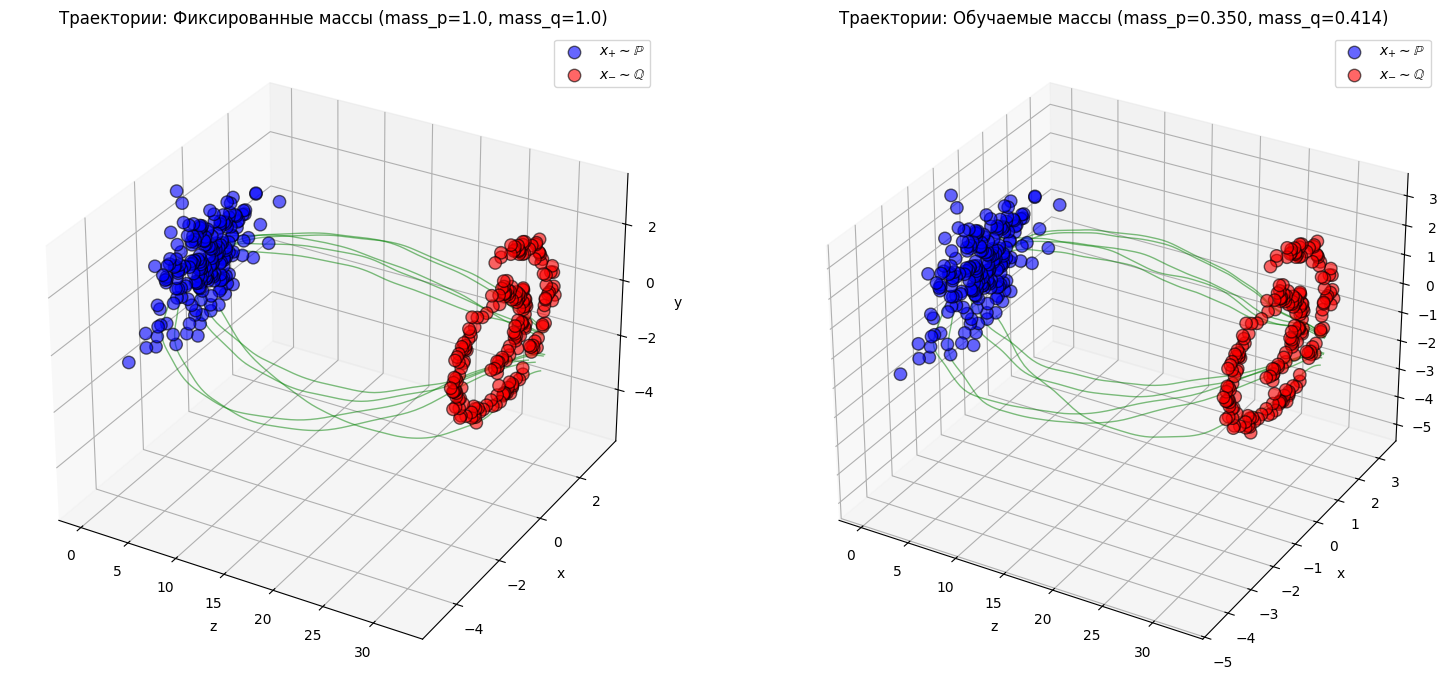

In [ ]:
# Визуализация траекторий для обеих моделей
print("Генерация траекторий для визуализации...")

# Траектории для модели с фиксированными массами
learned_ode_fixed = LearnDippoleEFMODESolver(net_fixed, config)
init_viz = p_dist.sample(50).to(config.device)
init_viz[:, 0] = config.training.epsilon

p_samples_viz = p_dist.sample(200).to(config.device)
q_samples_viz = q_dist.sample(200).to(config.device)

try:
    p_samples_ode = torch.cat([config.p.x_loc*torch.ones(len(p_samples_viz))[:,None].to(config.device),
                               p_samples_viz[:,1:]], dim=1)
    q_samples_ode = torch.cat([config.q.x_loc*torch.ones(len(q_samples_viz))[:,None].to(config.device),
                              q_samples_viz[:,1:]], dim=1)
    
    _, traj_fixed = learned_ode_fixed(init_viz.clone(), p_samples_ode, q_samples_ode)
    traj_fixed = torch.stack(traj_fixed, dim=0)
except Exception as e:
    print(f"Ошибка при генерации траекторий (фиксированные): {e}")
    # Fallback: используем ground truth ODE solver
    ode_solver = DippoleGroundTrurthEFMODESolver(config)
    _, traj_fixed = ode_solver(efm_fixed, init_viz.clone(), p_samples_ode, q_samples_ode)
    traj_fixed = torch.stack(traj_fixed, dim=0)

# Траектории для модели с обучаемыми массами
try:
    learned_ode_learnable = LearnDippoleEFMODESolver(net_learnable, config)
    _, traj_learnable = learned_ode_learnable(init_viz.clone(), p_samples_ode, q_samples_ode)
    traj_learnable = torch.stack(traj_learnable, dim=0)
except Exception as e:
    print(f"Ошибка при генерации траекторий (обучаемые): {e}")
    ode_solver = DippoleGroundTrurthEFMODESolver(config)
    _, traj_learnable = ode_solver(efm_learnable, init_viz.clone(), p_samples_ode, q_samples_ode)
    traj_learnable = torch.stack(traj_learnable, dim=0)

# Извлекаем конечные точки траекторий (y ~ T(x+))
if len(traj_fixed.shape) == 3:
    final_points_fixed = traj_fixed[-1]  # Последний шаг для всех траекторий
else:
    final_points_fixed = None

if len(traj_learnable.shape) == 3:
    final_points_learnable = traj_learnable[-1]  # Последний шаг для всех траекторий
else:
    final_points_learnable = None

# Визуализация: 3D графики траекторий
fig = plt.figure(figsize=(16, 14))

# Верхний ряд: 3D графики траекторий
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax1.scatter(p_samples_viz[:,0].detach().cpu(), p_samples_viz[:,1].detach().cpu(), p_samples_viz[:,2].detach().cpu(),
           color='blue', edgecolor='black', s=80, label=r'$x_{+} \sim \mathbb{P}$', alpha=0.6)
ax1.scatter(q_samples_viz[:,0].detach().cpu(), q_samples_viz[:,1].detach().cpu(), q_samples_viz[:,2].detach().cpu(),
           color='red', edgecolor='black', s=80, label=r'$x_{-} \sim \mathbb{Q}$', alpha=0.6)

# Показываем несколько траекторий
for i in range(min(10, len(init_viz))):
    if len(traj_fixed.shape) == 3:
        ax1.plot(traj_fixed[:, i, 0].detach().cpu(), 
                traj_fixed[:, i, 1].detach().cpu(),
                traj_fixed[:, i, 2].detach().cpu(),
                color='green', alpha=0.5, linewidth=1)

ax1.set_title('Траектории: Фиксированные массы (mass_p=1.0, mass_q=1.0)')
ax1.legend()
ax1.set_xlabel('z')
ax1.set_ylabel('x')
ax1.set_zlabel('y')

# Модель с обучаемыми массами (3D)
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
ax2.scatter(p_samples_viz[:,0].detach().cpu(), p_samples_viz[:,1].detach().cpu(), p_samples_viz[:,2].detach().cpu(),
           color='blue', edgecolor='black', s=80, label=r'$x_{+} \sim \mathbb{P}$', alpha=0.6)
ax2.scatter(q_samples_viz[:,0].detach().cpu(), q_samples_viz[:,1].detach().cpu(), q_samples_viz[:,2].detach().cpu(),
           color='red', edgecolor='black', s=80, label=r'$x_{-} \sim \mathbb{Q}$', alpha=0.6)

for i in range(min(10, len(init_viz))):
    if len(traj_learnable.shape) == 3:
        ax2.plot(traj_learnable[:, i, 0].detach().cpu(), 
                traj_learnable[:, i, 1].detach().cpu(),
                traj_learnable[:, i, 2].detach().cpu(),
                color='green', alpha=0.5, linewidth=1)

ax2.set_title(f'Траектории: Обучаемые массы (mass_p={final_mass_p:.3f}, mass_q={final_mass_q:.3f})')
ax2.legend()
ax2.set_xlabel('z')
ax2.set_ylabel('x')
ax2.set_zlabel('y')

# Нижний ряд: 2D графики y ~ T(x+)
# Модель с фиксированными массами (2D проекция)
ax3 = fig.add_subplot(2, 2, 3)
if final_points_fixed is not None:
    # Проекция на плоскость x-y (координаты 1 и 2)
    ax3.scatter(final_points_fixed[:, 1].detach().cpu(), 
               final_points_fixed[:, 2].detach().cpu(),
               color='purple', edgecolor='black', s=100, marker='*', 
               label=r'$y \sim T(x_{+})$', alpha=0.8, linewidths=1.5)
    # Также показываем целевое распределение для сравнения
    ax3.scatter(q_samples_viz[:,1].detach().cpu(), q_samples_viz[:,2].detach().cpu(),
               color='red', edgecolor='black', s=60, label=r'$x_{-} \sim \mathbb{Q}$', alpha=0.6)
    ax3.scatter(p_samples_viz[:,1].detach().cpu(), p_samples_viz[:,2].detach().cpu(),
               color='blue', edgecolor='black', s=60, label=r'$x_{+} \sim \mathbb{P}$', alpha=0.6)
    
ax3.set_title('y ~ T(x+): Фиксированные массы (проекция на плоскость x-y)')
ax3.legend()
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.grid(True, alpha=0.3)

# Модель с обучаемыми массами (2D проекция)
ax4 = fig.add_subplot(2, 2, 4)
if final_points_learnable is not None:
    # Проекция на плоскость x-y (координаты 1 и 2)
    ax4.scatter(final_points_learnable[:, 1].detach().cpu(), 
               final_points_learnable[:, 2].detach().cpu(),
               color='purple', edgecolor='black', s=100, marker='*', 
               label=r'$y \sim T(x_{+})$', alpha=0.8, linewidths=1.5)
    # Также показываем целевое распределение для сравнения
    ax4.scatter(q_samples_viz[:,1].detach().cpu(), q_samples_viz[:,2].detach().cpu(),
               color='red', edgecolor='black', s=60, label=r'$x_{-} \sim \mathbb{Q}$', alpha=0.6)
    ax4.scatter(p_samples_viz[:,1].detach().cpu(), p_samples_viz[:,2].detach().cpu(),
               color='blue', edgecolor='black', s=60, label=r'$x_{+} \sim \mathbb{P}$', alpha=0.6)
    
ax4.set_title(f'y ~ T(x+): Обучаемые массы (проекция на плоскость x-y)')
ax4.legend()
ax4.set_xlabel('x')
ax4.set_ylabel('y')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
